In [31]:
import pandas as pd
import scipy.stats as stats
import numpy as np

In [83]:
stats = pd.read_csv("stats.csv")
stats = stats.rename(columns={'night.mmdd': 'night'})
stats["night"] = stats["night"].astype("category")
stats["site"] = stats["site"].astype("category")
stats["count_small"] = stats["count_small"].astype(float)
stats["count_medium-small"] = stats["count_medium-small"].astype(float)
stats["count_medium-large"] = stats["count_medium-large"].astype(float)
stats["count_large"] = stats["count_large"].astype(float)
stats = stats[["night","site","count_small", "count_medium-small","count_medium-large","count_large"]]

size_cols = [
    "count_small",
    "count_medium-small",
    "count_medium-large",
    "count_large"
]
stats["total_count"] = stats[size_cols].sum(axis=1)
stats
              

,night,site,count_small,count_medium-small,count_medium-large,count_large,total_count
0,611,WS1,57.0,74.0,4.0,5.0,140.0
1,620,WS1,39.0,40.0,7.0,7.0,93.0
2,628,WS1,28.0,23.0,7.0,6.0,64.0
3,705,WS1,44.0,11.0,5.0,0.0,60.0
4,712,WS1,28.0,23.0,3.0,0.0,54.0
5,720,WS1,20.0,10.0,2.0,0.0,32.0
6,724,WS1,15.0,6.0,4.0,1.0,26.0
7,802,WS1,15.0,5.0,1.0,0.0,21.0
8,816,WS1,42.0,14.0,1.0,0.0,57.0
9,819,WS1,44.0,9.0,2.0,0.0,55.0


## Hypothesis Testing By Site

Control Variable: Site	
Ho: equal	
Ha: unequal	
Hypothesis: Ho, reason: Proof of Concept itself	
alpha: 0.05

ANOVA

In [76]:
from scipy.stats import f_oneway
import pandas as pd
import pprint

groups_by_site = {} # stores total_count of moths per night acroos all classes.

for i, group in stats[["site","total_count"]].groupby("site"):
    groups_by_site.update({str(i):list(group["total_count"])})

print("\n")
print("One site, multiple record dates, irrespective of Size,, Abundance on a Sheet")
print("\n")
pprint.pprint(groups_by_site, width=160)

# print(*groups_by_site.values())
f_stat, p_value = f_oneway(*groups_by_site.values())
print("\n" + "=" * 60)
print("Hypothesis Testing for first control variable: Site")
print("=" * 60 + "\n")
print("F_statistic:", round(f_stat,4))
print("p_value: ", p_value)
print("alpha: ", 0.05 )
print("Is there Much variability across sites: ", p_value < 0.05)



One site, multiple record dates, irrespective of Size,, Abundance on a Sheet


{'WS1': [140.0, 93.0, 64.0, 60.0, 54.0, 32.0, 26.0, 21.0, 57.0, 55.0, 37.0, 43.0, 35.0, 15.0],
 'WS4': [88.0, 30.0, 90.0, 82.0, 37.0, 68.0, 40.0, 54.0, 43.0, 20.0, 19.0],
 'WS5': [169.0, 96.0, 65.0, 63.0, 69.0, 52.0, 65.0, 43.0, 53.0, 18.0, 14.0],
 'WS6low': [85.0, 84.0, 23.0, 36.0, 22.0, 15.0, 27.0, 25.0, 10.0],
 'WS6up': [82.0, 90.0, 35.0, 74.0, 23.0, 11.0, 31.0, 24.0]}

Hypothesis Testing for first control variable: Site

F_statistic: 0.9614
p_value:  0.4372940699386082
alpha:  0.05
Is there Much variability across sites:  False


In [111]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm


model = ols("total_count ~ C(site)", data=stats).fit()
anova_table = anova_lm(model, typ=2)

print("\n" + "=" * 60)
print("Hypothesis Testing for first control variable: Site")
print("=" * 60 + "\n")

anova_table


Hypothesis Testing for first control variable: Site



,sum_sq,df,F,PR(>F)
C(site),4086.250061,4.0,0.961406,0.437294
Residual,51003.448052,48.0,NaN,NaN


MANOVA

In [78]:
from statsmodels.multivariate.manova import MANOVA

maov = MANOVA.from_formula(
    'count_small + Q("count_medium-small") + Q("count_medium-large") + count_large ~ C(site) + C(night)',
    data=stats
)
print("\n" + "=" * 60)
print("Hypothesis Testing for first control variable - Site" + '\n' + "Controling for in Night")
print("=" * 60 + "\n")

print(maov.mv_test())


Hypothesis Testing for first control variable - Site
Controling for in Night

                   Multivariate linear model
                                                               
---------------------------------------------------------------
          Intercept        Value  Num DF  Den DF F Value Pr > F
---------------------------------------------------------------
             Wilks' lambda 0.0995 4.0000 32.0000 72.3920 0.0000
            Pillai's trace 0.9005 4.0000 32.0000 72.3920 0.0000
    Hotelling-Lawley trace 9.0490 4.0000 32.0000 72.3920 0.0000
       Roy's greatest root 9.0490 4.0000 32.0000 72.3920 0.0000
---------------------------------------------------------------
                                                               
---------------------------------------------------------------
         C(site)         Value   Num DF  Den DF  F Value Pr > F
---------------------------------------------------------------
           Wilks' lambda 0.5427 16.0000  98.

## Hypothesis Testing by Night

In [79]:
from scipy.stats import f_oneway
import pandas as pd
import pprint

groups_by_night = {} # stores total_count of moths per night acroos all classes.

for i, group in stats[["night", "site", "total_count"]].groupby("night"):
    groups_by_night.update({str(i):list(group["total_count"])})

print("\n")
print("One night, multiple record sites, irrespective of size, Abundance on a Sheet")
print("\n")
pprint.pprint(groups_by_night, width=160)

f_stat, p_value = f_oneway(*groups_by_night.values())
print("\n" + "=" * 60)
print("Hypothesis Testing for Second control variable: Night")
print("=" * 60 + "\n")
print("F_statistic:", round(f_stat,4))
print("p_value: ", p_value)
print("alpha: ", 0.05 )
print("Is there Much variability across nights: ", p_value < 0.05)



One night, multiple record sites, irrespective of size, Abundance on a Sheet


{'611': [140.0, 88.0, 169.0, 82.0],
 '620': [93.0, 96.0, 90.0],
 '628': [64.0, 30.0, 65.0, 85.0, 35.0],
 '705': [60.0, 90.0, 63.0, 84.0, 74.0],
 '712': [54.0, 82.0, 69.0],
 '720': [32.0, 37.0, 52.0, 23.0],
 '724': [26.0, 68.0, 65.0, 36.0, 23.0],
 '802': [21.0, 22.0, 11.0],
 '816': [57.0, 43.0, 31.0],
 '819': [55.0, 40.0, 53.0],
 '904': [37.0, 54.0, 15.0],
 '909': [43.0, 43.0, 27.0],
 '923': [35.0, 20.0, 18.0, 25.0, 24.0],
 '930': [15.0, 19.0, 14.0, 10.0]}

Hypothesis Testing for Second control variable: Night

F_statistic: 10.2884
p_value:  6.57966893750658e-09
alpha:  0.05
Is there Much variability across nights:  True


In [112]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm


model = ols("total_count ~ C(night)", data=stats).fit()
anova_table = anova_lm(model, typ=2)

print("\n" + "=" * 60)
print("Hypothesis Testing for first control variable: Night")
print("=" * 60 + "\n")

anova_table


Hypothesis Testing for first control variable: Night



,sum_sq,df,F,PR(>F)
C(night),42652.614780,13.0,10.288413,6.579669e-09
Residual,12437.083333,39.0,NaN,NaN


## Hypothesis Testing by Size

MULTIPLE OPTIONS OF GROUPING/AGGREGATE VALUES FOR SIZEBINS, 

1. Total Value across Sites for each Night. (imo not a valid form of distribution, total is highly dependent on days active) 
2. Total Value across Nights for each Site. (imo not a valid form of distribution, total is highly dependent on days active)
3. Average Value across Sites for each Night. - 17 values, one for each night, using sites to average, better also because we failed to reject the null Hypothesis!
4. Average Value across Nights, for each Site. - 4 values, 1 for each site. i think bad representation, since there is variation among sites and we rejected the null hypothesis 

Proceeding with option 3.

In [98]:
# sites = ["WS1", "WS4", "WS5","WS6low", "WS6up"]
sizes = ["count_small","count_medium-small","count_medium-large", "count_large"]
groups_by_size = {}

for i, group in stats[["night",*sizes]].groupby("night"):
    # pprint.pprint(i)
    # pprint.pprint(group)
    for size in sizes:
        if size in groups_by_size:
            groups_by_size[size].append(np.mean(group[size]))
        else:
            groups_by_size[size] = [np.mean(group[size])]

print("\n")
print("One size, aveg on multiple record sites, for each night, condiering each night as ONE big sheet.")
print("\n")

pprint.pprint(groups_by_size, width= 350)


f_stat, p_value = f_oneway(*groups_by_size.values())
print("\n" + "=" * 60)
print("Hypothesis Testing for Second control variable: Size")
print("=" * 60 + "\n")
print("F_statistic:", round(f_stat,4))
print("p_value: ", p_value)
print("alpha: ", 0.05 )
print("Is there Much variability across Sizes: ", p_value < 0.05)




One size, aveg on multiple record sites, for each night, condiering each night as ONE big sheet.


{'count_large': [6.75, 5.333333333333333, 2.6, 0.8, 0.3333333333333333, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 'count_medium-large': [4.75, 6.666666666666667, 5.0, 4.2, 3.6666666666666665, 1.25, 2.2, 1.0, 1.6666666666666667, 1.3333333333333333, 0.3333333333333333, 1.0, 2.2, 0.75],
 'count_medium-small': [58.0, 36.0, 20.8, 16.0, 19.333333333333332, 8.25, 11.6, 5.333333333333333, 15.333333333333334, 11.333333333333334, 6.0, 12.333333333333334, 7.0, 7.25],
 'count_small': [50.25, 45.0, 27.4, 53.2, 45.0, 26.5, 29.6, 11.666666666666666, 26.666666666666668, 36.666666666666664, 29.0, 24.333333333333332, 15.2, 6.5]}

Hypothesis Testing for Second control variable: Size

F_statistic: 25.5906
p_value:  2.6297150660229885e-10
alpha:  0.05
Is there Much variability across Sizes:  True


In [110]:
rows = []

for size, values in groups_by_size.items():
    for value in values:
        rows.append({
            "size": size,
            "count": value
        })

anova_df = pd.DataFrame(rows)
anova_df["count"] = anova_df["count"].astype(float)
anova_df["size"] = anova_df["size"].astype("category")
display(anova_df)

model = ols("count ~ C(size)", data=anova_df).fit()
anova_table = anova_lm(model, typ=2)

anova_table

,size,count
0,count_small,50.250000
1,count_small,45.000000
2,count_small,27.400000
3,count_small,53.200000
4,count_small,45.000000
5,count_small,26.500000
6,count_small,29.600000
7,count_small,11.666667
8,count_small,26.666667
9,count_small,36.666667


,sum_sq,df,F,PR(>F)
C(size),7970.694896,3.0,25.590623,2.629715e-10
Residual,5398.802282,52.0,NaN,NaN


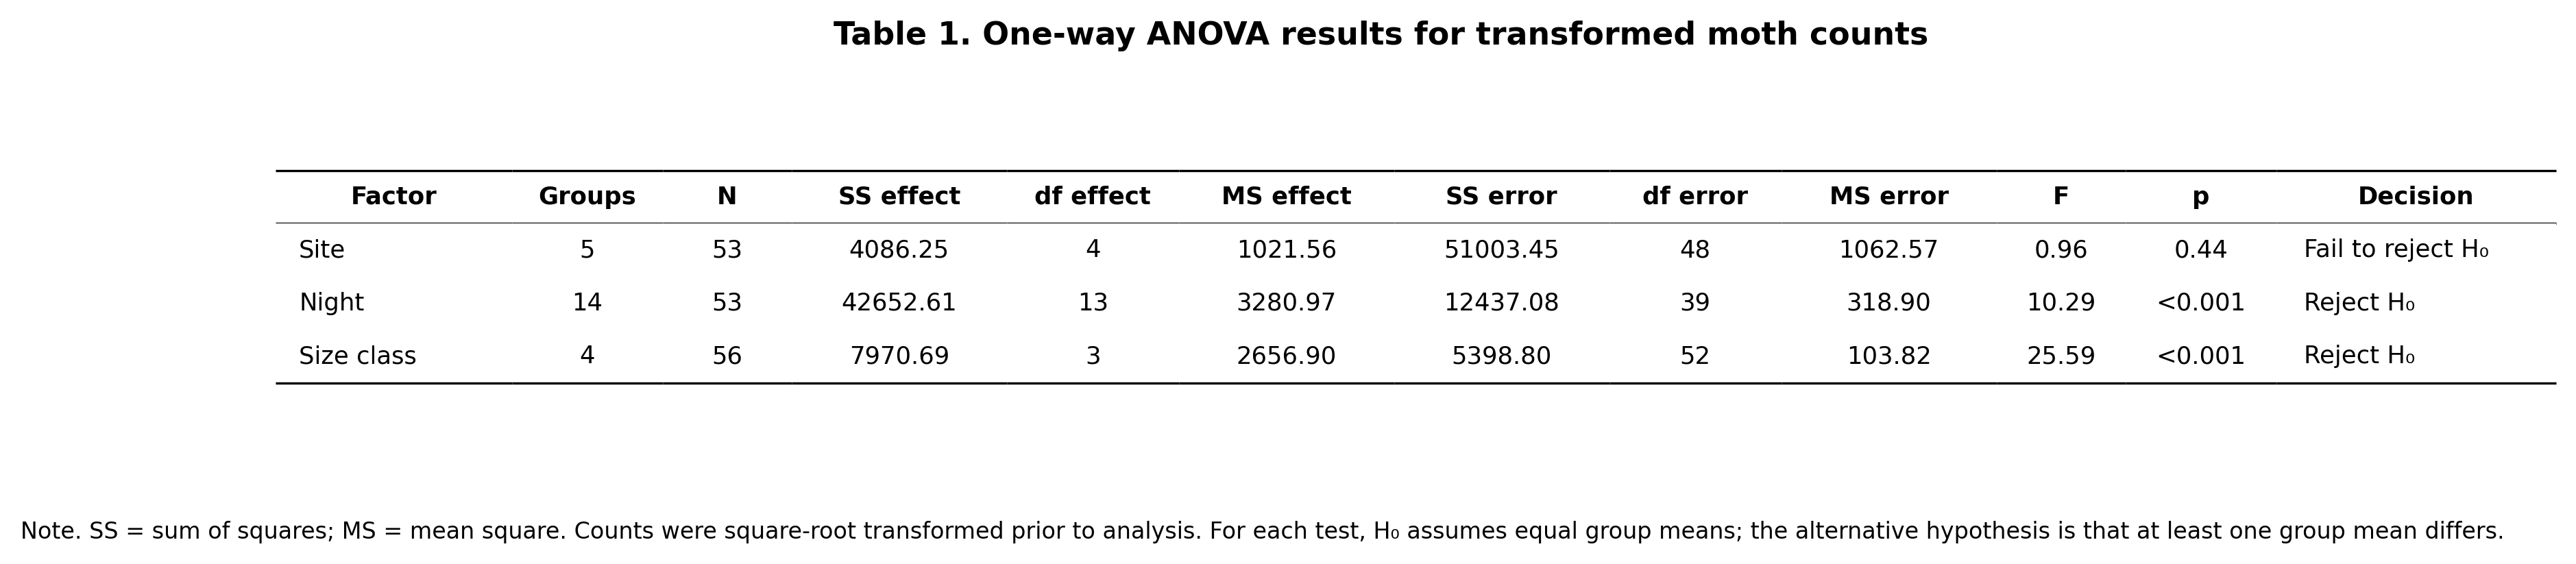

In [118]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Clean, research-style ANOVA table
# -----------------------------
anova_table = pd.DataFrame({
    "Factor": ["Site", "Night", "Size class"],
    "Groups": [5, 14, 4],
    "N": [53, 53, 56],
    "SS effect": [4086.25, 42652.61, 7970.69],
    "df effect": [4, 13, 3],
    "MS effect": [1021.56, 3280.97, 2656.90],
    "SS error": [51003.45, 12437.08, 5398.80],
    "df error": [48, 39, 52],
    "MS error": [1062.57, 318.90, 103.82],
    "F": [0.96, 10.29, 25.59],
    "p": ["0.44", "<0.001", "<0.001"],
    "Decision": ["Fail to reject H₀", "Reject H₀", "Reject H₀"]
})

# Format numeric columns
for col in ["SS effect", "MS effect", "SS error", "MS error", "F"]:
    anova_table[col] = anova_table[col].map(lambda x: f"{x:.2f}")

# -----------------------------
# Draw table
# -----------------------------
fig, ax = plt.subplots(figsize=(13.5, 2.8), dpi=300)
ax.axis("off")

col_widths = [
    0.11,  # Factor
    0.07,  # Groups
    0.06,  # N
    0.10,  # SS effect
    0.08,  # df effect
    0.10,  # MS effect
    0.10,  # SS error
    0.08,  # df error
    0.10,  # MS error
    0.06,  # F
    0.07,  # p
    0.13   # Decision
]

table = ax.table(
    cellText=anova_table.values,
    colLabels=anova_table.columns,
    cellLoc="center",
    colLoc="center",
    colWidths=col_widths,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.55)

# Remove all cell borders first
for (row, col), cell in table.get_celld().items():
    cell.set_facecolor("white")
    cell.set_edgecolor("white")
    cell.set_linewidth(0)

# Header styling
n_cols = len(anova_table.columns)

for col in range(n_cols):
    cell = table[(0, col)]
    cell.set_text_props(weight="bold")
    cell.visible_edges = "TB"
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)

# Bottom rule
last_row = len(anova_table)
for col in range(n_cols):
    cell = table[(last_row, col)]
    cell.visible_edges = "B"
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)

# Left-align first and decision columns
factor_col = anova_table.columns.get_loc("Factor")
decision_col = anova_table.columns.get_loc("Decision")

for row in range(1, len(anova_table) + 1):
    table[(row, factor_col)].get_text().set_ha("left")
    table[(row, decision_col)].get_text().set_ha("left")

# Title
fig.suptitle(
    "Table 1. One-way ANOVA results for transformed moth counts",
    fontsize=11,
    fontweight="bold",
    y=0.94
)

# Note
fig.text(
    0.01, 0.04,
    "Note. SS = sum of squares; MS = mean square. Counts were square-root transformed prior to analysis. "
    "For each test, H₀ assumes equal group means; the alternative hypothesis is that at least one group mean differs.",
    ha="left",
    fontsize=8
)

plt.savefig("../graphs/anova_table_clean.png", bbox_inches="tight", dpi=300)
plt.savefig("../graphs/anova_table_clean.pdf", bbox_inches="tight")
plt.savefig("../graphs/anova_table_clean.svg", bbox_inches="tight")

plt.show()